## Import Modules

In [ ]:
import pandas as pd
import numpy as np

Unique values per column:


,0
timestamp_created,1401464
timestamp_updated,1401150
author_last_played,1366779
review,1143450
author_steamid,577739
weighted_vote_score,158973
author_playtime_forever,131302
author_playtime_at_review,85231
appid,27569
author_playtime_last_two_weeks,6409


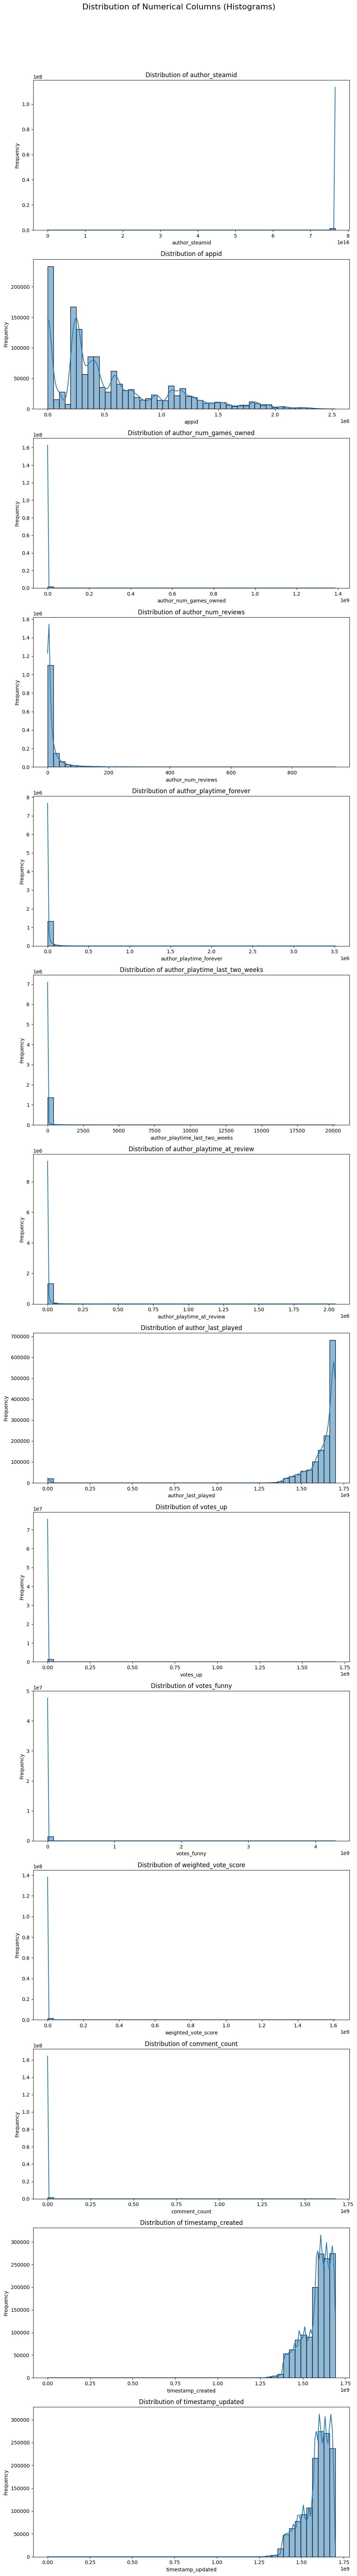

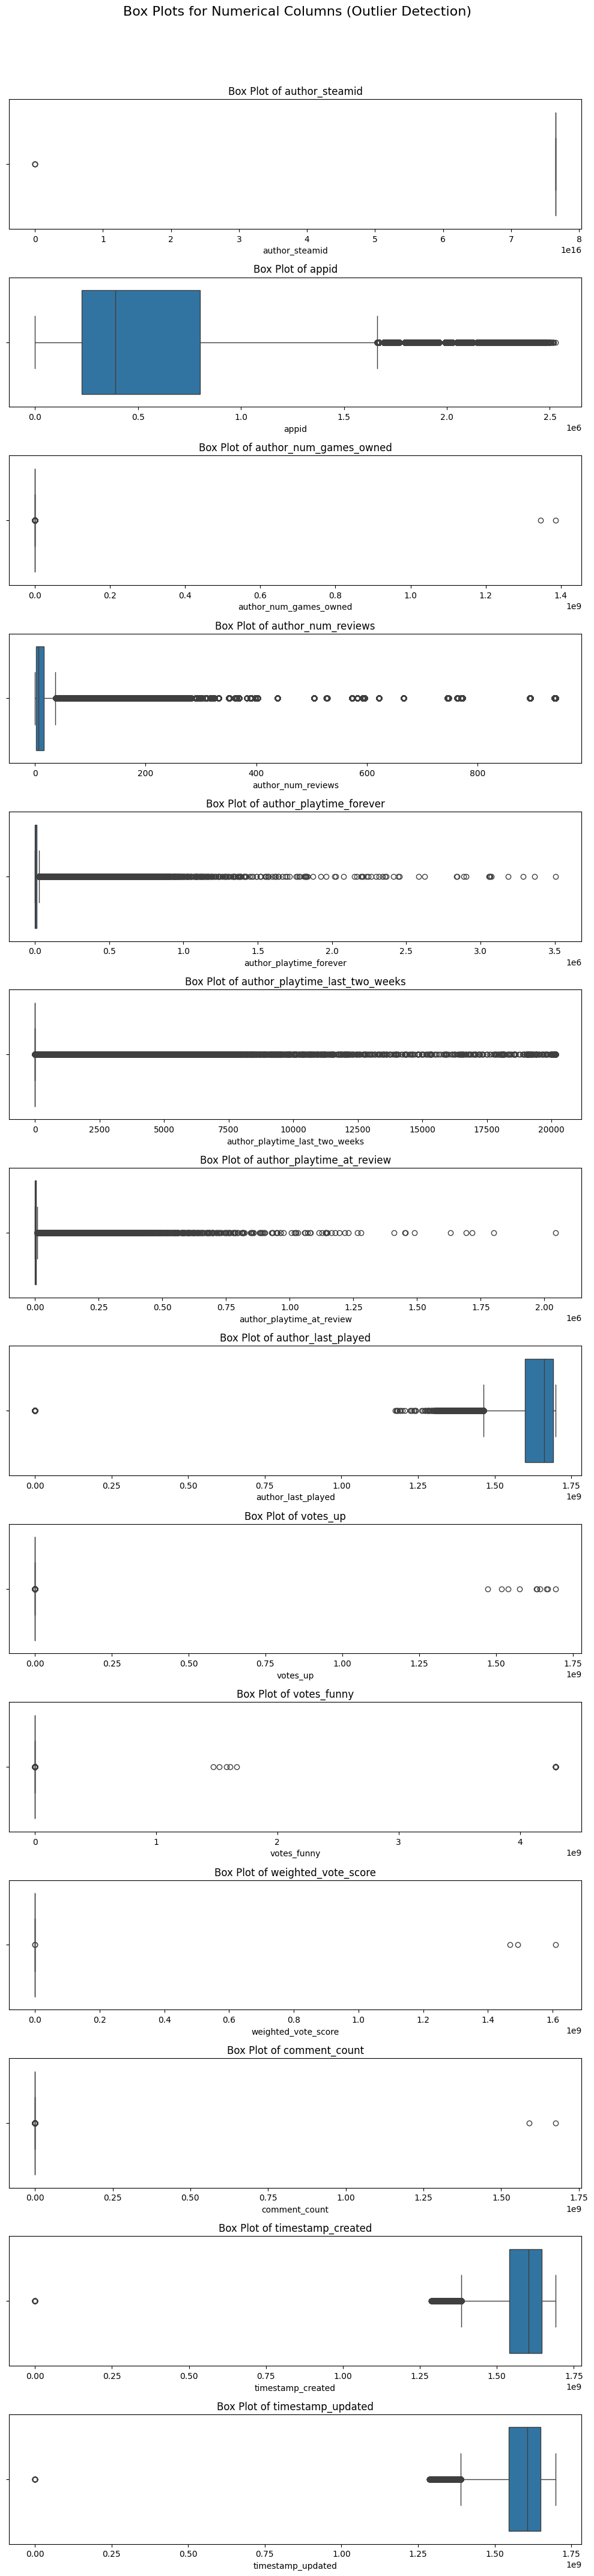

In [ ]:
# For numerical columns, let's visualize their distribution with histograms to spot outliers.
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for histograms
numeric_cols = df.select_dtypes(include=['number']).columns

if not numeric_cols.empty:
    fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=1, figsize=(10, 5 * len(numeric_cols)))
    fig.suptitle('Distribution of Numerical Columns (Histograms)', y=1.02, fontsize=16)

    if len(numeric_cols) == 1:
        axes = [axes] # Ensure axes is iterable even for a single subplot

    for i, col in enumerate(numeric_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=50)
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns to plot histograms for.")

# Also check box plots for outliers for numerical columns
if not numeric_cols.empty:
    fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=1, figsize=(10, 3 * len(numeric_cols)))
    fig.suptitle('Box Plots for Numerical Columns (Outlier Detection)', y=1.02, fontsize=16)

    if len(numeric_cols) == 1:
        axes = [axes]

    for i, col in enumerate(numeric_cols):
        sns.boxplot(x=df[col], ax=axes[i])
        axes[i].set_title(f'Box Plot of {col}')
        axes[i].set_xlabel(col)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns to plot box plots for.")

### (3) Automated EDA (SweetViz & YData Profiling)

Automated EDA tools are fantastic for quickly getting a comprehensive overview of your data. Because these tools are extremely computationally expensive, we will use a **random sample of 50,000 rows** to generate the reports. This prevents Out-Of-Memory (OOM) crashes while still providing statistically representative insights.

In [ ]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.1 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport

# Take a representative sample to avoid running out of memory
sample_df = df.sample(n=50000, random_state=42)

print("Generating YData Profiling Report...")
# We use minimal=True to further save memory and computation time for large datasets
profile = ProfileReport(sample_df, title="Steam Reviews YData Profile Report", minimal=True)

# Display inline in the notebook
profile.to_notebook_iframe()

# You can also save it to an HTML file to download and share
profile.to_file("ydata_profiling_report.html")

/tmp/ipykernel_1596/2465593689.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Generating YData Profiling Report...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 17/17 [00:04<00:00,  3.91it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
profile.to_file("ydata_profiling_report.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]